# Pre-Delivery Walkthrough: SCHISM + SFINCS over the Mendocino Coast

End-to-end demo of the `coastal_calibration` library and `nwm_coastal`
QGIS plugin against a single Pacific coastal subdomain (Mendocino /
Point Arena, CA). The walkthrough covers:

1. **Draw the SCHISM subset polygon** in QGIS with the plugin's
   Draw Polygon tool, then save it as `extract_poly.geojson`.
2. **Extract** a sub-mesh from the full Pacific SCHISM domain using
   that polygon, then run the SCHISM pipeline on the subdomain.
3. **Derive the SFINCS inputs** in QGIS: turn the extracted SCHISM
   mesh boundary into an SFINCS AOI polygon and pick the NWM
   flowlines that enter the domain.
4. **Build & run** the SFINCS model on the same boundary.
5. **Compare** modeled water levels against a NOAA CO-OPS tide gauge
   in a single 3-line plot (Observed, SCHISM, SFINCS).
6. **Animate** SCHISM and SFINCS water-level fields side-by-side with
   a shared colorbar.

Both simulations are 50 hours long and run locally in roughly 4 minutes
each on this machine; no HPC is required.

## 0. Setup

The walkthrough runs out of `docs/examples/walkthrough/`. That
directory is committed with the four input GeoJSONs the demo needs
(`extract_poly.geojson`, `aoi.geojson`, `refine_poly.geojson`,
`discharge_nwm.geojson`). Sections 1 and 3 below document the QGIS
steps that produce these files. The full Pacific SCHISM mesh and
the WRF geogrid are not redistributable, so they live as symlinks
(`model`, `geo_em_CONUS.nc`) pointing at the proprietary data drive
(see `docs/examples/README.md` for how to set them up).

In [1]:
from __future__ import annotations

import os
from pathlib import Path

notebook_dir = Path.cwd()  # assumes run from docs/examples/notebooks/
walkthrough_dir = (notebook_dir.parent / "walkthrough").resolve()
os.chdir(walkthrough_dir)

required = (
    "model",  # symlink to proprietary Pacific SCHISM mesh
    "geo_em_CONUS.nc",  # symlink to proprietary WRF geogrid
    "extract_poly.geojson",  # SCHISM subset polygon
    "aoi.geojson",  # SFINCS AOI (mesh boundary unioned with NHF divides)
    "refine_poly.geojson",  # SFINCS quadtree refinement zone
    "discharge_nwm.geojson",  # NWM flowlines crossing the AOI
)
missing = [n for n in required if not (walkthrough_dir / n).exists()]
if missing:
    raise FileNotFoundError(
        f"Required walkthrough inputs missing: {missing}. "
        "See docs/examples/README.md for setup instructions."
    )

print(f"Working directory: {walkthrough_dir}")
print("Inputs:")
for name in required:
    p = walkthrough_dir / name
    if p.is_symlink():
        kind = f"symlink -> {p.resolve()}"
    elif p.is_file():
        kind = f"file ({p.stat().st_size / 1e3:.1f} KB)"
    else:
        kind = "missing"
    print(f"  {name:<28s} {kind}")

Working directory: docs/examples/walkthrough
Inputs:
  model                        symlink -> /Volumes/data/schism_models/pacific
  geo_em_CONUS.nc              symlink -> /Volumes/data/schism_models/geo_em_CONUS.nc
  extract_poly.geojson         file (1.3 KB)
  aoi.geojson                  file (131.6 KB)
  refine_poly.geojson          file (223.9 KB)
  discharge_nwm.geojson        file (58.4 KB)


## 1. QGIS plugin: draw the SCHISM subset polygon

The walkthrough starts in QGIS, where the `nwm_coastal` plugin turns
the full Pacific SCHISM mesh into a coastal subset polygon. The
output of this section is `extract_poly.geojson`, the first input
that the SCHISM pipeline in Section 2 consumes.

**The walkthrough has this file pre-staged** in
`docs/examples/walkthrough/extract_poly.geojson`, so the SCHISM
section below runs without QGIS. The steps below document how it
was produced.

### Step 1: Install the plugin and view the toolbar

After installing the plugin, restart QGIS. The `nwm_coastal` toolbar
appears as the highlighted row of icons below, with one icon per
pipeline step in left-to-right order.

![nwm_coastal toolbar in QGIS](../images/plugin_window.png)

### Step 2: Add the NHF basemap

Click **Add Basemap** (first plugin icon). Point the dialog at the
National HydroFabric `.gpkg` (or `.gdb`) for this region. Tick the
layers you need (Divides, Flowpaths, Gages, Nexus) and check
**Include CO-OPS stations** to also auto-download nearby NOAA tide
gauges. An optional *Flowpaths Override* lets you swap in an
alternate flowpaths source without re-staging the whole NHF dataset.

![Add Basemap dialog](../images/plugin_basemap.png)

The plugin loads each layer with default styling: flowpaths in blue,
divides in light yellow, gages and nexus as point layers, CO-OPS
gauges as orange stars, over an OpenStreetMap base.

![Basemap loaded](../images/plugin_basemap_loaded.png)

### Step 3: Load the Pacific SCHISM mesh

Click **Load SCHISM Mesh** and select the full Pacific mesh
`hgrid.gr3`. The plugin streams the mesh into QGIS as the `hgrid`
triangular mesh layer over the NHF basemap.

![Pacific SCHISM mesh loaded over basemap](../images/plugin_load_schism.png)

### Step 4: Draw and save the subset polygon

Zoom into the coastal area of interest (here, the Mendocino /
Point Arena coast). Click **Draw Polygon** from the plugin toolbar,
then click on the map to place vertices that bound the subset, and
double-click to finish the polygon. With the new polygon layer
selected, click **Save Polygon** from the plugin to write
`extract_poly.geojson` into the walkthrough directory (WGS84). The
SCHISM pipeline in the next section reads this file directly.

![Draw Polygon over the Pacific SCHISM mesh](../images/plugin_extract_schism.png)

## 2. Extract a SCHISM subdomain

`extract_mesh` keeps the portion of the full Pacific SCHISM mesh that
falls inside the polygon and rebuilds the open boundaries where the
polygon edge crosses the mesh. The result is a small, self-contained
project under `extracted/` ready for the pipeline runner.

In [2]:
import shapely

import coastal_calibration.schism.subsetter as ss

poly = shapely.get_geometry(shapely.from_geojson(Path("extract_poly.geojson").read_text()), 0)
print(f"Polygon: {poly.geom_type}, bounds={[round(b, 3) for b in poly.bounds]}")

res = ss.extract_mesh("model", poly, ".", output_name="extracted")
print(
    f"Extracted: {res.classification.n_side_a:,} nodes, {res.subset.side_a.n_elements:,} elements"
)

Polygon: Polygon, bounds=[-123.856, 38.819, -123.616, 39.289]
Extracted: 16,508 nodes, 30,213 elements


### Run the SCHISM pipeline

The runner executes the 12 stages: download, sflux, atmospheric
regridding, boundary conditions, NWM discharge, mesh partitioning,
SCHISM execution, and post-processing (station comparison + obs-points
extraction). On this machine the full 50-hour simulation completes in
roughly 4 minutes.

In [3]:
from coastal_calibration import CoastalCalibConfig, CoastalCalibRunner, configure_logger

configure_logger(level="INFO")

schism_run_dir = walkthrough_dir / "run_schism"

schism_config = CoastalCalibConfig.from_dict(
    {
        "model": "schism",
        "simulation": {
            "start_date": "2025-11-26",
            "duration_hours": 50,
            "coastal_domain": "pacific",
            "meteo_source": "nwm_ana",
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": str(schism_run_dir),
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./extracted",
            "geogrid_file": "./geo_em_CONUS.nc",
            "discharge_file": "./extracted/nwmReaches.csv",
            "nodes": 1,
            "ntasks_per_node": 8,
            "nscribes": 2,
            "oversubscribe": True,
            "include_noaa_gages": True,
        },
    }
)

schism_result = CoastalCalibRunner(schism_config).run()
if not schism_result.success:
    raise RuntimeError(
        f"SCHISM pipeline failed at '{schism_result.stages_failed}': {schism_result.errors}"
    )
print(schism_result)

Coastal Calibration Workflow                                                    
Start Time: 2026-05-14 20:01:35                                                 
----------------------------------------                                        
Cleaned generated files from                                                    
docs/examples/walkthrough/run_schism      
Stage: download                                                                 
Start Time: 2026-05-14 20:01:35                                                 
  Download input data (NWM, STOFS)                                              
  meteo/nwm_ana: 51/51 [OK]                                                     
  hydro/nwm: 51/51 [OK]                                                         
  coastal/stofs: 1/1 [OK]                                                       
  Total: 103/103 (failed: 0)                                                    
  Download complete. Raw files stored in                          

WorkflowResult: SUCCESS
  Start:     2026-05-14 20:01:35
  End:       2026-05-14 20:06:02
  Duration:  4m 27s
  Completed: download, schism_forcing_prep, schism_forcing, schism_sflux, schism_params, schism_obs, schism_boundary, schism_discharge, schism_prep, schism_run, schism_postprocess, schism_plot


## 3. QGIS plugin: derive the SFINCS AOI and discharge flowlines

With the SCHISM subset built and run, return to QGIS to produce the
two SFINCS-side inputs:

1. **`aoi.geojson`**: a polygon that aligns the seaward edge of the
   SFINCS domain with the SCHISM mesh boundary and snaps the landward
   edge to NHF watershed divides.
2. **`discharge_nwm.geojson`**: the NWM flowlines that cross the AOI
   boundary, keyed by an integer NWM feature ID (column name passed
   to the SFINCS create stage as `nwm_id_column`; the create stage
   normalizes it to `"name"` internally so the run stage can look up
   NWM streamflow regardless of the source column name).

**The walkthrough has both files pre-staged** in
`docs/examples/walkthrough/`, so Sections 4-6 are runnable today.
The steps below document how those files were produced.

### Step 1: Clear the map

The QGIS session from Section 1 still has the full Pacific SCHISM
mesh and other intermediate layers loaded. Click **Clear Map** from
the plugin to drop the SCHISM-related layers and leave only the NHF
basemap behind, giving a clean slate for the SFINCS-side work.

![Clear Map button on the plugin toolbar](../images/plugin_clear.png)

### Step 2: Load the subset SCHISM mesh

Click **Load SCHISM Mesh** and select `extracted/hgrid.gr3` from
this walkthrough directory. The plugin loads the subset mesh as the
`hgrid` triangular mesh layer over the NHF basemap.

### Step 3: Extract the mesh boundary and load NWM reaches

Click **Extract Mesh Boundary**. The plugin parses the open,
exterior, and island boundaries from `hgrid.gr3` and adds a
`mesh_boundary` polygon layer that traces the SCHISM domain edge
exactly. This polygon is the seaward seed for the SFINCS AOI.

Then click **Load NWM Reaches** from the plugin. This adds the sink
and source points of the subset SCHISM model as a visual guide for
which NWM reaches enter and leave the domain, helping you pick the
right flowpaths in Step 6 below.

![Mesh boundary polygon and NWM sink/source points over the SCHISM mesh](../images/plugin_schism_mesh.png)

### Step 4: Union the boundary with NHF divides and save the AOI

In the QGIS Layers panel, select the `mesh_boundary` layer. Use the
QGIS **Select Features** tool to click on and select the polygon on
the map. With the polygon selected, click **NHF Union** from the
plugin. The plugin extends the boundary inland to fully include
every NHF watershed divide it clips, producing a `merged_polygon`
layer. This is what makes the SFINCS domain hydrologically
meaningful: every river entering the domain has its full upstream
catchment inside the AOI, so NWM discharge sources line up with
watershed boundaries. With the `merged_polygon` layer selected and
its polygon selected on the map, click **Save Polygon** from the
plugin to write `aoi.geojson` (WGS84) into the walkthrough directory.

![merged_polygon: SCHISM boundary unioned with NHF divides](../images/plugin_divide_union.png)

### Step 5: Select and export discharge flowpaths

Select the `flowpaths` layer in the Layers panel. With the QGIS
**Select Features** tool, select every river that crosses the AOI
boundary (the NWM sink/source points loaded in Step 3 show you
which ones enter or exit the domain). Once the right flowpaths are
selected, click **Export Selected Flowpaths** from the plugin and
save as `discharge_nwm.geojson`. The file keeps the source NHF
integer ID column (`ID` for the demo dataset), which is what the
SFINCS create stage uses to map flowlines back to NWM streamflow.

![Selected discharge flowpaths inside the AOI](../images/plugin_discharge_flowpath.png)

The setup cell at the top of this notebook expects
`extract_poly.geojson`, `aoi.geojson`, and `discharge_nwm.geojson`
to live in `docs/examples/walkthrough/`. All three are committed
alongside the notebook so this section can be skipped end-to-end on
a re-run. To use a different domain, regenerate them with the steps
above and drop them into the walkthrough directory under the same
names.

## 4. Build & run the SFINCS model

`SfincsCreateConfig.from_dict` bundles every input the model needs:
the AOI polygon, a base 512 m quadtree grid with one refinement level
inside the AOI, NOAA CRM 3 arc-second (~90 m) topobathy + GEBCO
elevation, ESA WorldCover-derived Manning's *n*, and the QGIS-derived
flowlines as discharge sources.  CRM is a public, integrated
topobathy product from NCEI THREDDS, and it resolves coastal bays
that the land-only Copernicus DEM misses.
`add_noaa_gages: True` also auto-discovers the same NOAA tide gauge
the SCHISM pipeline uses, which is what makes the 3-line comparison
in Part 4 work without any manual station bookkeeping.

In [4]:
from coastal_calibration import SfincsCreateConfig, SfincsCreator

create_config = SfincsCreateConfig.from_dict(
    {
        "aoi": "./aoi.geojson",
        "output_dir": "./output_sfincs",
        "download_dir": "../downloads/walkthrough_grid",
        "grid": {
            "resolution": 512,
            "crs": "utm",
            "rotated": False,
            # Refine along the coast (SCHISM mesh boundary) rather than
            # the full NHF-union AOI: the coastal corridor is where
            # SFINCS needs higher resolution to keep narrow connections
            # wet across the tidal cycle. Level 4 = 32 m cells.
            "refinement": [
                {"polygon": "./refine_poly.geojson", "level": 4, "buffer_m": -200},
            ],
        },
        "elevation": {
            "datasets": [
                {
                    "name": "noaa_crm",
                    "zmin": -20000,
                    "source": "noaa_crm",
                },
                {"name": "gebco_15arcs", "zmin": -20000, "source": "gebco_15arcs"},
            ],
            "buffer_cells": 1,
        },
        "mask": {
            "zmin": -50.0,
            "boundary_zmax": -1.0,
            "reset_bounds": True,
            # Drop tiny isolated active cells just above zmin (offshore
            # bumps that clear the -50 m cutoff but are surrounded by
            # deeper inactive cells) so the model is a single connected
            # domain instead of a few floating fragments.
            "keep_largest_only": True,
        },
        "subgrid": {
            "nr_subgrid_pixels": 4,
            "lulc_dataset": "esa_worldcover",
            "manning_land": 0.04,
            "manning_sea": 0.02,
        },
        "river_discharge": {
            "flowlines": "./discharge_nwm.geojson",
            # `nwm_reaches.geojson` from the QGIS plugin uses "ID" for the
            # NWM feature ID; create.py renames it to "name" internally so
            # the run stage's NWM streamflow lookup works regardless.
            "nwm_id_column": "ID",
        },
        "add_noaa_gages": True,
    }
)

create_result = SfincsCreator(create_config).run()
if not create_result.success:
    raise RuntimeError(
        f"SFINCS create failed at '{create_result.stages_failed}': {create_result.errors}"
    )
print(create_result)

Coastal Calibration Workflow                                                    
Start Time: 2026-05-14 20:06:04                                                 
----------------------------------------                                        
Stage: create_grid                                                              
Start Time: 2026-05-14 20:06:04                                                 
  Create SFINCS grid from AOI                                                   
  AOI:                                                                          
docs/examples/walkthrough/aoi.geojson     
  Resolution: 512 m, CRS: utm                                                   
  Refinement polygon 'refine_poly.geojson': split into 2 component(s) after     
buffer_m=-200 m                                                                 
  Refinement: 1 polygon(s), max level 4                                         
  Grid created successfully                                       

WorkflowResult: SUCCESS
  Start:     2026-05-14 20:06:04
  End:       2026-05-14 20:06:33
  Duration:  29s
  Completed: create_grid, create_fetch_data, create_elevation, create_mask, create_boundary, create_discharge, create_subgrid, create_obs, create_write


In [5]:
sfincs_run_dir = walkthrough_dir / "run_sfincs"

sfincs_run_config = CoastalCalibConfig.from_dict(
    {
        "model": "sfincs",
        "simulation": {
            "start_date": "2025-11-26",
            "duration_hours": 50,
            "coastal_domain": "pacific",
            "meteo_source": "nwm_ana",
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": str(sfincs_run_dir),
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./output_sfincs",
            "discharge_locations_file": "./output_sfincs/sfincs_nwm.src",
            "merge_discharge": True,
            "forcing_to_mesh_offset_m": 0.0,
            # NAVD88→LMSL offset for Mendocino (~39N, -123.7W) from NOAA VDatum.
            # Verify / re-derive for other domains via:
            # https://vdatum.noaa.gov/vdatumweb/api/convert?s_x=<lon>&s_y=<lat>&s_z=0&region=westcoast&s_h_frame=NAD83_2011&s_v_frame=NAVD88&t_h_frame=IGS14&t_v_frame=LMSL
            "vdatum_mesh_to_msl_m": -0.92,
            "include_precip": True,
            "include_wind": True,
            "include_pressure": True,
            "floodmap_dem": "../downloads/walkthrough_grid/noaa_crm.tif",
            # Stability settings tuned for tidal + compound flooding on a
            # finely refined coastal mesh. ``advection=0`` is the
            # standard SFINCS choice for tide-dominated runs (advection
            # destabilises shallow water at low tide on quadtree
            # transitions); a small constant viscosity damps residual
            # high-frequency noise. Same family of settings as the
            # Lavaca demo (``docs/examples/notebooks/lavaca.py``).
            "run_param_overrides": {
                "tspinup": 10800,
                "advection": 0,
                "viscosity": 0,
                "nuvisc": 0.01,
            },
        },
    }
)

sfincs_result = CoastalCalibRunner(sfincs_run_config).run()
if not sfincs_result.success:
    raise RuntimeError(
        f"SFINCS pipeline failed at '{sfincs_result.stages_failed}': {sfincs_result.errors}"
    )
print(sfincs_result)

Coastal Calibration Workflow                                                    
Start Time: 2026-05-14 20:06:33                                                 
----------------------------------------                                        
Cleaned generated files from                                                    
docs/examples/walkthrough/run_sfincs      
Stage: download                                                                 
Start Time: 2026-05-14 20:06:33                                                 
  Download input data (NWM, STOFS)                                              
  meteo/nwm_ana: 51/51 [OK]                                                     
  hydro/nwm: 51/51 [OK]                                                         
  coastal/stofs: 1/1 [OK]                                                       
  Total: 103/103 (failed: 0)                                                    
  Download complete. Raw files stored in                          

WorkflowResult: SUCCESS
  Start:     2026-05-14 20:06:33
  End:       2026-05-14 20:13:29
  Duration:  6m 55s
  Completed: download, sfincs_symlinks, sfincs_data_catalog, sfincs_init, sfincs_timing, sfincs_forcing, sfincs_discharge, sfincs_precip, sfincs_wind, sfincs_pressure, sfincs_write, sfincs_run, sfincs_floodmap, sfincs_plot


## 5. Compare water levels at the NOAA gauge

Each pipeline writes `obs_water_level.parquet` to its run directory,
a station × time table of modeled water levels at every observation
point picked up during post-processing (in this domain, just the one
CO-OPS gauge that lies inside both meshes). Combined with a fresh
`query_coops_byids` call for the matching observed series, we feed
both runs into `plot_station_comparison` and get a single figure with
**Observed**, **SCHISM**, and **SFINCS** lines per station.

In [6]:
from datetime import timedelta

import pandas as pd

from coastal_calibration.data.coops_api import COOPSAPIClient, query_coops_byids
from coastal_calibration.plotting import plot_station_comparison

schism_obs_parquet = schism_run_dir / "obs_water_level.parquet"
sfincs_obs_parquet = sfincs_run_dir / "sfincs_model" / "obs_water_level.parquet"

schism_series = pd.read_parquet(schism_obs_parquet)
sfincs_series = pd.read_parquet(sfincs_obs_parquet)
print(f"SCHISM obs columns: {list(schism_series.columns)}")
print(f"SFINCS obs columns: {list(sfincs_series.columns)}")

# Keep only the CO-OPS station IDs (numeric 7-digit codes).
common_stations = sorted(set(schism_series.columns) & set(sfincs_series.columns))
station_ids = [s for s in common_stations if s.isdigit() and len(s) == 7]
if not station_ids:
    raise RuntimeError(
        "No NOAA CO-OPS station appears in both runs' obs_water_level.parquet. "
        "Check that `add_noaa_gages` (SFINCS) and `include_noaa_gages` (SCHISM) "
        "both selected at least one gauge in the domain."
    )
print(f"Comparison stations: {station_ids}")

# Re-fetch CO-OPS observations for the simulation window and convert to MSL.
sim = schism_config.simulation
begin_date = sim.start_date.strftime("%Y%m%d %H:%M")
end_dt = sim.start_date + timedelta(hours=sim.duration_hours)
end_date = end_dt.strftime("%Y%m%d %H:%M")

obs_ds = query_coops_byids(
    station_ids,
    begin_date,
    end_date,
    product="water_level",
    datum="MLLW",
    units="metric",
    time_zone="gmt",
)

datums = COOPSAPIClient().get_datums(station_ids)
datum_map = {d.station_id: d for d in datums}
for sid in station_ids:
    d = datum_map.get(sid)
    if d is None:
        continue
    msl = d.get_datum_value("MSL")
    mllw = d.get_datum_value("MLLW")
    if msl is None or mllw is None:
        continue
    offset = msl - mllw
    if d.units == "feet":
        offset *= 0.3048
    obs_ds.water_level.loc[{"station": sid}] -= offset
obs_ds.attrs["datum"] = "MSL"

# Build (times, elevation[n_t, n_stations]) tuples in the column order of station_ids.
schism_pair = (
    schism_series.index.to_numpy(),
    schism_series[station_ids].to_numpy(),
)
sfincs_pair = (
    sfincs_series.index.to_numpy(),
    sfincs_series[station_ids].to_numpy(),
)

walkthrough_figs = walkthrough_dir / "figs"
walkthrough_figs.mkdir(exist_ok=True)
combined_paths = plot_station_comparison(
    {"SCHISM": schism_pair, "SFINCS": sfincs_pair},
    station_ids,
    walkthrough_figs,
    obs_ds=obs_ds,
)
print(f"Wrote {len(combined_paths)} comparison figure(s) to {walkthrough_figs}")

  Loading cached station metadata from cache/coops_stations_metadata.json       
  Requesting water_level data for 1 station(s) from 20251126 00:00 to 20251128  
02:00                                                                           
  Fetching data from 1 station(s)                                               


SCHISM obs columns: ['9416841']
SFINCS obs columns: ['9416841']
Comparison stations: ['9416841']


  Successfully retrieved data for 1 station(s)                                  
  Loading cached station metadata from cache/coops_stations_metadata.json       
  Fetching datum information for 1 station(s)                                   
  Fetching data from 1 station(s)                                               


Wrote 1 comparison figure(s) to docs/examples/walkthrough/figs


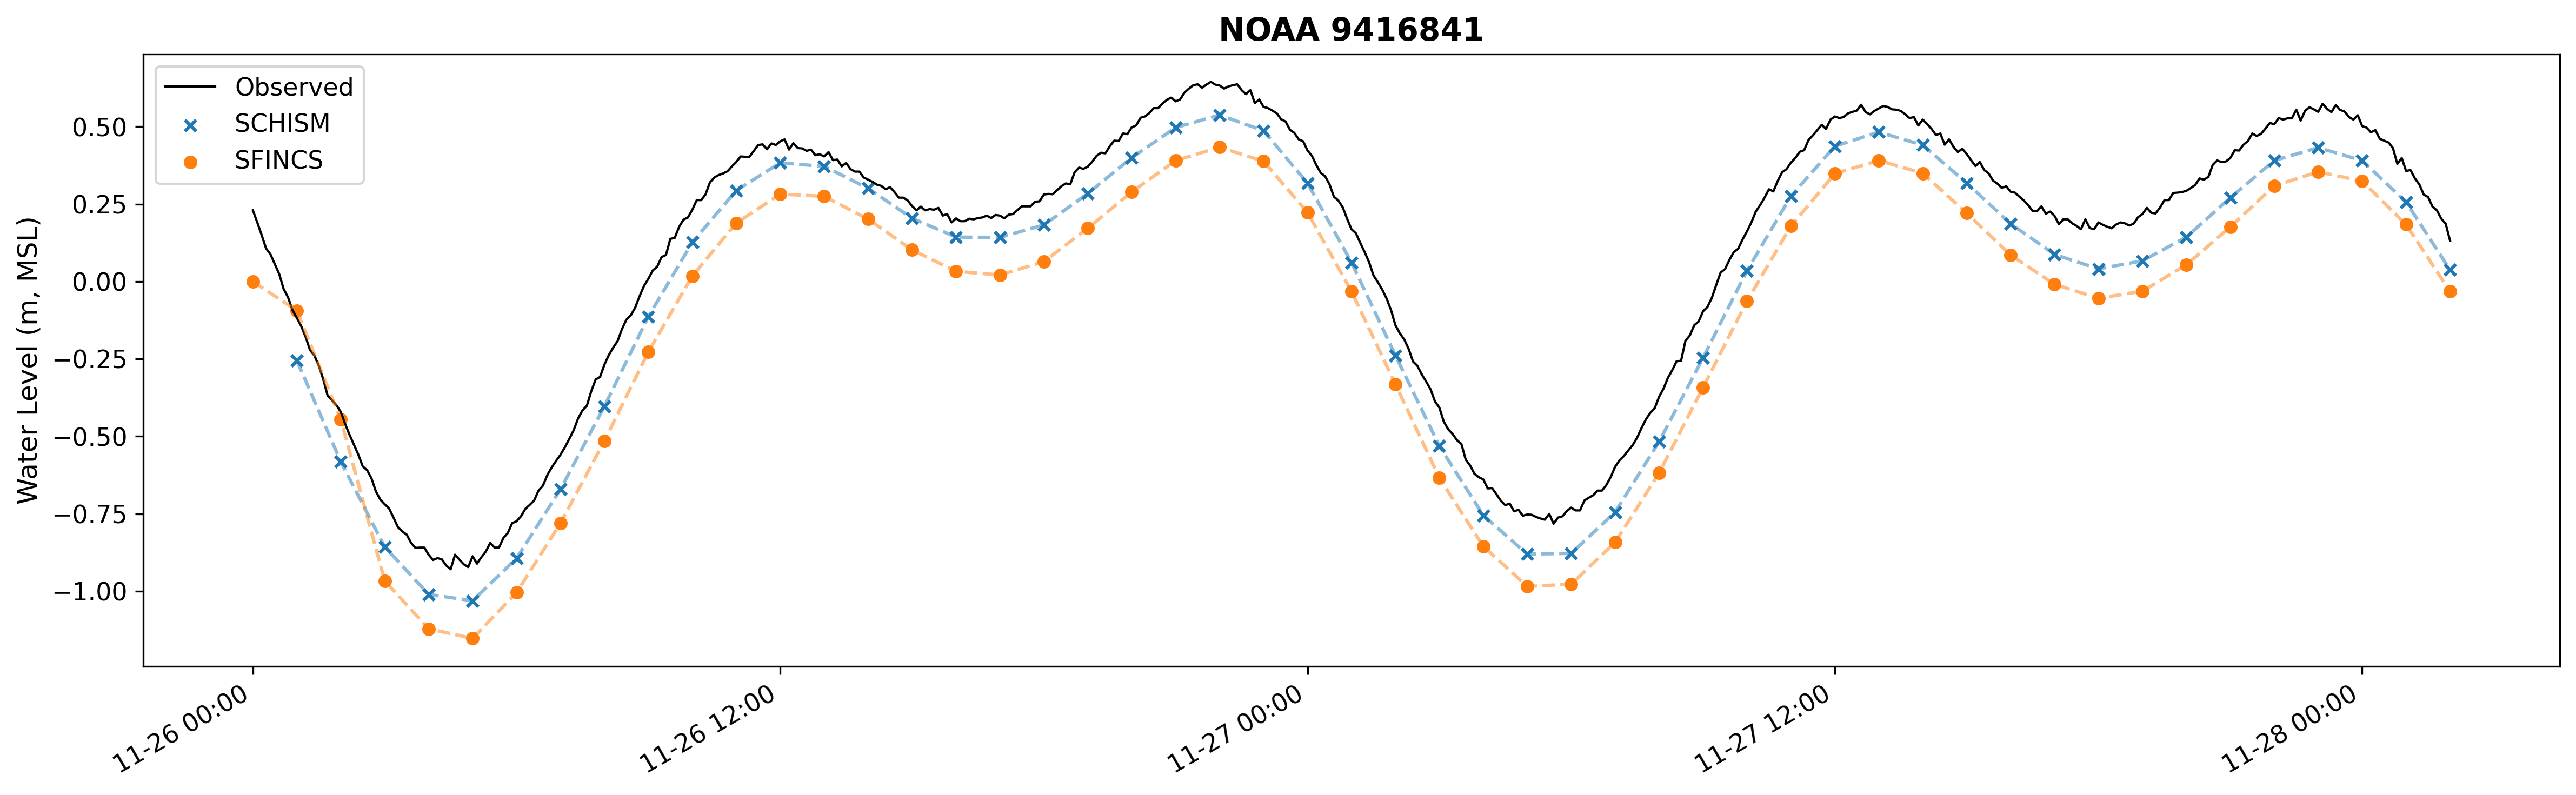

In [7]:
from IPython.display import Image, display

for png in combined_paths:
    display(Image(filename=str(png), width=900))

## 6. Side-by-side spatial animation

`animate_water_level_comparison` renders two panels driven by their
own datasets but locked to a shared colormap range and synchronised
on a common time clock. The two models output at different cadences
(SCHISM hourly, SFINCS half-hourly), so the function takes the
intersection of their time coverage, picks the coarser axis as the
master clock, and uses nearest-neighbour lookup to populate the
other panel each frame.

### A note on the river channels

Both models show water at the upstream NWM inflow points but not
along the river course down to the ocean. This is not a bug; it is
a property of the **NOAA CRM topobathy DEM**: at 3 arc-second
(~90 m) the CRM resolves the seaward bathymetry of the bay but is
still too coarse to carve narrow river channels into the inland part
of the grid. The model bed along the rivers therefore sits at the
surrounding land elevation (tens of meters above MSL), so river
discharge from `nwm_reaches.geojson` deposits water on a "high" bed:
a small puddle forms at the inflow point but cannot flow downhill
over a bed that is already above the water surface.

Tightening the visualization's wet-cell threshold from 0.05 m to
0.0 m exposes the thin film of water that does propagate, but the
rest of the river course genuinely has `h ≤ 0` in the model output.
A proper fix needs a hydro-conditioned DEM (rivers burned into the
topobathy), which is intentionally **out of scope** for this demo.

In [8]:
from coastal_calibration.plotting import animate_water_level_comparison
from coastal_calibration.schism.outputs import load_schism_elevation
from coastal_calibration.sfincs.outputs import load_sfincs_water_level

schism_ds = load_schism_elevation(
    schism_run_dir,
    correction_file=walkthrough_dir / "extracted" / "elevation_correction.csv",
)
sfincs_ds = load_sfincs_water_level(sfincs_run_dir / "sfincs_model")
print(f"SCHISM: {dict(schism_ds.sizes)}, mesh_type={schism_ds.attrs['mesh_type']}")
print(f"SFINCS: {dict(sfincs_ds.sizes)}, mesh_type={sfincs_ds.attrs['mesh_type']}")

SCHISM: {'time': 50, 'node': 16508, 'face': 30213, 'face_node': 4}, mesh_type=ugrid-triangle-or-quad
SFINCS: {'time': 51, 'face': 124595, 'node': 498380, 'face_node': 4}, mesh_type=ugrid-quadtree


In [9]:
from IPython.display import Video

side_by_side = animate_water_level_comparison(
    schism_ds,
    sfincs_ds,
    walkthrough_figs / "schism_vs_sfincs.mp4",
    labels=("SCHISM", "SFINCS"),
    fps=8,
    time_stride=2,
    cmap="viridis",
    figsize=(16, 7),
    title_prefix="Mendocino: water-level comparison",
    # Lower the wet-cell threshold so the thin film of water near
    # the river inflows is visible (see the note above on rivers).
    dry_threshold=0.0,
)
print(f"Wrote {side_by_side.name}  ({side_by_side.stat().st_size / 1024:.0f} KB)")

Video(str(side_by_side), embed=True, width=900)

wrote                                                                           
docs/examples/walkthrough/figs/schism_vs_s
fincs.mp4 (25 frames, 8 fps, master=left)                                       


Wrote schism_vs_sfincs.mp4  (232 KB)


## Summary

The walkthrough exercised the full client-facing surface of the
library plus the QGIS plugin:

- **QGIS plugin (extract polygon)**: *Add Basemap*, *Load SCHISM
  Mesh*, *Draw Polygon*, and *Save Polygon* produced
  `extract_poly.geojson` from the full Pacific mesh.
- **Subdomain extraction**: `extract_mesh` carved a Mendocino
  subdomain from the 3.1 M-node Pacific mesh in seconds.
- **Unified pipeline runner**: the same `CoastalCalibRunner` ran a
  12-stage SCHISM job and, with a different config, a 14-stage
  SFINCS job on the matching domain.
- **QGIS plugin (SFINCS inputs)**: *Clear Map*, *Load SCHISM Mesh*,
  *Extract Mesh Boundary*, *NHF Union*, *Save Polygon*, *Load NWM
  Reaches*, and *Export Selected Flowpaths* chained the SCHISM mesh
  boundary into a hydrologically meaningful SFINCS AOI and a
  discharge-flowline geojson.
- **3-line comparison**: `plot_station_comparison` overlaid
  Observed, SCHISM, and SFINCS series at the shared CO-OPS gauge.
- **Side-by-side animation**: `animate_water_level_comparison`
  rendered the two model fields with a single shared colorbar,
  handling the two different output cadences automatically.